## TODO Updates Applied
- Remove `price_per_room` feature if present.
- Remove `city_avg_price_sqm`, `city_furnished_avg_price_sqm`, and target-encoded address.
- Use dynamic current year.
- Recommend nested CV for target encoding.


# Egyptian Residential Real Estate — Price Prediction Pipeline

A production-quality, leak-safe regression pipeline that predicts **asking prices** (EGP) for
Egyptian residential listings scraped from OLX / Dubizzle.

**Key design principles**

- A single editable `CSV_PATH` at the top; everything else runs automatically.
- Robust, **hierarchical** outlier detection on `price_per_sqm` based on local market segments
  (no fixed global thresholds).
- Arabic-aware text normalization and structured information extraction from free text.
- **Cross-fitted target encoding** — every target-derived feature is computed *inside* CV folds only,
  so there is no leakage from validation/test rows into training features.
- The target is modeled as `log1p(price_value)` and inverted with `expm1`.
- Five base learners (Ridge, Random Forest, XGBoost, LightGBM, CatBoost) plus a geometric-mean
  ensemble in log space.

> **Important caveat.** This dataset contains **asking prices**, not realized transaction prices.
> Predictions therefore model *what sellers ask*, not *what buyers pay*. An R² above ~0.90 should be
> treated as a **red flag for target leakage**, not as a success.


## 1. Imports

In [97]:
import os, re, json, warnings, unicodedata
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Imports ready. SHAP available:", SHAP_AVAILABLE)

Imports ready. SHAP available: False


## 2. Configuration

`CSV_PATH` is the **only** value you normally need to edit. All thresholds below are sensible
defaults used by the hierarchical cleaner and the encoders.

In [98]:
# ---- THE ONLY VARIABLE YOU NEED TO EDIT ----
CSV_PATH = r"C:\Users\bdalr\ultimate-scraper\OLXX.csv"
# --------------------------------------------

TARGET = "price_value"

# Hierarchical outlier-detection settings
MIN_GROUP_SIZE   = 30      # a group must have >= this many rows to be trusted
MAD_Z_THRESHOLD  = 3.5     # modified z-score cutoff (Iglewicz & Hoaglin)
IQR_K            = 2.2     # Tukey fence multiplier (slightly loose for skewed RE data)
QUANTILE_CLIP    = (0.005, 0.995)  # global safety clip on price_per_sqm

# Cross-fitting / validation
N_FOLDS    = 5
TEST_SIZE  = 0.20
TE_SMOOTH  = 20.0          # target-encoding smoothing (shrinkage toward global mean)

OUTPUT_DIR = "artifacts"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configuration loaded. Target =", TARGET)

Configuration loaded. Target = price_value


## 3. Data Loading

The scraped file is *mostly* UTF-8 but contains a handful of stray invalid bytes, so we read with
`encoding_errors="replace"`. We immediately coerce the obvious numeric columns and quarantine
non-numeric noise (the scraper occasionally shifts columns, leaving Arabic text in `bathrooms`).

In [99]:
def load_raw(path: str) -> pd.DataFrame:
    """Load the scraped CSV robustly regardless of stray non-UTF8 bytes."""
    df = pd.read_csv(path, encoding="utf-8", encoding_errors="replace")
    df.columns = [c.replace("\ufeff", "").replace("ï»¿", "").strip() for c in df.columns]
    return df

raw = load_raw(CSV_PATH)
print("Raw shape:", raw.shape)
print("Columns:", list(raw.columns))
raw.head(3)

Raw shape: (8942, 32)
Columns: ['listing_id', 'title', 'price', 'price_value', 'area_sqm', 'bedrooms', 'bathrooms', 'city', 'district', 'property_type', 'listing_type', 'url', 'image_url', 'photos', 'posted', 'page_number', 'detail_purpose', 'detail_ownership', 'detail_furnished', 'detail_payment_method', 'detail_property_status', 'detail_location_address', 'detail_all', 'description', 'features', 'seller_name', 'seller_profile_url', 'seller_verified', 'seller_member_since', 'detail_error', 'map_image_path', 'map_image_error']


,listing_id,title,price,price_value,area_sqm,bedrooms,bathrooms,city,district,property_type,listing_type,url,image_url,photos,posted,page_number,detail_purpose,detail_ownership,detail_furnished,detail_payment_method,detail_property_status,detail_location_address,detail_all,description,features,seller_name,seller_profile_url,seller_verified,seller_member_since,detail_error,map_image_path,map_image_error
0,502927385,دوبلكس فيو بحيرة استلام 6 شهور في صواري,"9,750,000 ج.م",9750000,249,4,3,محرّم بيك,صواري,دوبلكس,for-sale,https://www.dubizzle.com.eg/ad/%D8%AF%D9%88%D8...,https://images.dubizzle.com.eg/thumbnails/1591...,10.0,منذ 2 أسابيع مكالمة واتساب شركة موثقة,1,للبيع,أول سكن,لا,كاش,قيد الإنشاء,صواري، محرّم بيك,غرض العقار: للبيع; ملكية: أول سكن; مفروش: لا; ...,دوبلكس فيو بحيرة استلام 6 شهور في صواري - مستش...,شرفة; أمن,Remax professional,https://www.dubizzle.com.eg/companies/remax-pr...,True,2023.0,NaN,NaN,NaN
1,503697249,شقة 62 متر غرفة نوم واحدة بتصميم عصري,"4,044,300 ج.م",4044300,62,1,1,البحر الأحمر,الغردقة,شقة,for-sale,https://www.dubizzle.com.eg/ad/%D8%B4%D9%82%D8...,https://images.dubizzle.com.eg/thumbnails/1761...,14.0,منذ 8 دقائق مكالمة,1,للبيع,أول سكن,لا,تقسيط,قيد الإنشاء,الغردقة، البحر الأحمر,غرض العقار: للبيع; ملكية: أول سكن; الطابق: 1; ...,شقة 62 متر غرفة نوم واحدة بتصميم عصري داخل منت...,شرفة; أجهزة المطبخ; حديقة خاصة; أمن; عداد مياه...,NaN,https://www.dubizzle.com.eg/companies/hda-5001718,False,2026.0,NaN,NaN,NaN
2,503697244,شقة 53 متر غرفة نوم واحدة مع حديقة خاصة 23 متر,"3,857,200 ج.م",3857200,53,1,1,البحر الأحمر,الغردقة,شقة,for-sale,https://www.dubizzle.com.eg/ad/%D8%B4%D9%82%D8...,https://images.dubizzle.com.eg/thumbnails/1761...,14.0,منذ 7 دقائق مكالمة,1,للبيع,أول سكن,لا,تقسيط,قيد الإنشاء,الغردقة، البحر الأحمر,غرض العقار: للبيع; ملكية: أول سكن; الطابق: 1; ...,منتجع الموج (El Mouj Resort) هو منتجع سكني متك...,شرفة; أجهزة المطبخ; حديقة خاصة; حمام سباحة; عد...,NaN,https://www.dubizzle.com.eg/companies/hda-5001718,False,2026.0,NaN,NaN,NaN


In [100]:
# Coerce numeric columns; non-numeric noise becomes NaN (handled in cleaning)
for col in ["price_value", "area_sqm", "bedrooms", "bathrooms"]:
    if col in raw.columns:
        raw[col] = pd.to_numeric(raw[col], errors="coerce")

print(raw[["price_value", "area_sqm", "bedrooms", "bathrooms"]].describe().T)

              count          mean           std       min        25%        50%        75%           max
price_value  8942.0  2.648097e+11  1.414198e+13  385000.0  4500000.0  6500000.0  9500000.0  1.302500e+15
area_sqm     8942.0  1.618649e+02  7.061790e+01      25.0      125.0      155.0      188.0  2.000000e+03
bedrooms     8942.0  2.733840e+00  7.796296e-01       1.0        2.0        3.0        3.0  1.000000e+01
bathrooms    8942.0  2.331469e+00  8.482648e-01       1.0        2.0        2.0        3.0  1.000000e+01


## 5. Arabic Text Processing

Defined early because cleaning and every extractor depend on it. Normalization:

- Strip diacritics (tashkeel) and tatweel (ـ).
- Unify alef variants (أ إ آ → ا), ya (ى → ي), and ta-marbuta (ة → ه).
- Convert Arabic-Indic digits (٠-٩) to ASCII so numeric regexes work on mixed text.
- Collapse punctuation/whitespace.

In [101]:
AR_DIACRITICS = re.compile(r"[\u0617-\u061A\u064B-\u0652\u0670\u0640]")
AR_INDIC = {ord(a): str(i) for i, a in enumerate("٠١٢٣٤٥٦٧٨٩")}
AR_INDIC.update({ord(a): str(i) for i, a in enumerate("۰۱۲۳۴۵۶۷۸۹")})  # extended

def normalize_arabic(text) -> str:
    """Normalize Arabic text for matching: unify letters, strip diacritics, map digits."""
    if not isinstance(text, str) or not text.strip():
        return ""
    t = unicodedata.normalize("NFKC", text)
    t = t.translate(AR_INDIC)
    t = AR_DIACRITICS.sub("", t)
    t = (t.replace("أ", "ا").replace("إ", "ا").replace("آ", "ا")
           .replace("ى", "ي").replace("ة", "ه").replace("ؤ", "و").replace("ئ", "ي"))
    t = re.sub(r"[^\w\u0600-\u06FF\s%.+/-]", " ", t)   # keep digits, arabic, a few symbols
    t = re.sub(r"\s+", " ", t).strip().lower()
    return t

# Quick sanity check
for s in ["شقة 115م², استلام ٢٠٢٨", "  Penthouse  دوبلكس  "]:
    print(repr(s), "->", repr(normalize_arabic(s)))

'شقة 115م², استلام ٢٠٢٨' -> 'شقه 115م2 استلام 2028'
'  Penthouse  دوبلكس  ' -> 'penthouse دوبلكس'


## 4. Data Cleaning

Steps, in order:

1. Drop exact duplicate listings (by `listing_id` if present, else by full-row hash).
2. Remove **impossible** records: missing/zero/negative target or area.
3. Repair shifted/garbled numeric fields (`bathrooms` sometimes holds Arabic place names).
4. Normalize the key Arabic categorical columns.
5. Compute `price_per_sqm`.
6. **Hierarchical** outlier removal (next subsection).

In [102]:
def basic_clean(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1. de-duplicate
    before = len(df)
    if "listing_id" in df.columns:
        df = df.drop_duplicates(subset="listing_id")
    df = df.drop_duplicates()
    print(f"Removed {before - len(df)} duplicate rows.")

    # 2. impossible records
    before = len(df)
    df = df[df[TARGET].notna() & (df[TARGET] > 0)]
    df = df[df["area_sqm"].notna() & (df["area_sqm"] > 0)]
    print(f"Removed {before - len(df)} rows with invalid target/area.")

    # 3. repair numeric noise: anything non-coercible already became NaN.
    #    Clamp absurd structural counts that come from column shifts.
    for col, hi in [("bedrooms", 12), ("bathrooms", 12)]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df.loc[(df[col] < 0) | (df[col] > hi), col] = np.nan

    # remove obviously broken extreme prices/areas before hierarchical step
    #   (kept very loose; hierarchical step does the real work)
    before = len(df)
    df = df[(df["area_sqm"] <= 5000)]
    df = df[(df[TARGET] >= 50_000) & (df[TARGET] <= 5e9)]
    print(f"Removed {before - len(df)} structurally impossible price/area rows.")

    return df.reset_index(drop=True)

clean = basic_clean(raw)
print("After basic clean:", clean.shape)

Removed 0 duplicate rows.
Removed 0 rows with invalid target/area.
Removed 30 structurally impossible price/area rows.
After basic clean: (8912, 32)


In [103]:
# 4. normalize key Arabic categoricals + compute price_per_sqm
TEXT_COLS = ["title", "description", "detail_all", "features", "detail_location_address"]
for c in TEXT_COLS:
    if c in clean.columns:
        clean[c + "_norm"] = clean[c].apply(normalize_arabic)

for c in ["city", "district", "property_type", "detail_furnished",
          "detail_ownership", "detail_payment_method", "detail_property_status"]:
    if c in clean.columns:
        clean[c] = clean[c].fillna("unknown").astype(str).str.strip()

clean["price_per_sqm"] = clean[TARGET] / clean["area_sqm"]
print(clean["price_per_sqm"].describe())

count    8.912000e+03
mean     5.078860e+04
std      4.502952e+04
min      2.400000e+03
25%      3.043682e+04
50%      4.500000e+04
75%      6.187907e+04
max      2.818792e+06
Name: price_per_sqm, dtype: float64


## 7. Compound Detection

The hierarchical cleaner groups by compound, so we detect compounds *before* outlier removal.
We match a curated dictionary of major Egyptian compounds against the normalized
`title + description + detail_all + district` text. Listings with no match get `"No Compound"`.

In [104]:
COMPOUND_PATTERNS = {
    "Madinaty":            [r"مدينتي", r"madinaty"],
    "Al Rehab":            [r"الرحاب", r"al ?rehab", r"rehab"],
    "Mountain View iCity": [r"ماونتن ?فيو ?اي ?سيتي", r"icity", r"i ?city"],
    "Mountain View":       [r"ماونتن ?فيو", r"mountain ?view"],
    "Hyde Park":           [r"هايد ?بارك", r"hyde ?park"],
    "Palm Hills":          [r"بالم ?هيلز", r"palm ?hills"],
    "SODIC":               [r"سوديك", r"sodic"],
    "Beverly Hills":       [r"بيفرلي ?هيلز", r"beverly ?hills"],
    "Swan Lake":           [r"سوان ?ليك", r"swan ?lake"],
    "Taj City":            [r"تاج ?سيتي", r"taj ?city"],
    "Sarai":               [r"سراي", r"sarai"],
    "Zed":                 [r"\bزيد\b", r"\bzed\b"],
    "Uptown Cairo":        [r"اب ?تاون", r"uptown ?cairo", r"uptown"],
    "Fifth Square":        [r"فيفث ?سكوير", r"fifth ?square"],
    "Villette":            [r"فيليت", r"villette"],
    "La Vista":            [r"لافيستا", r"la ?vista"],
    "Stone Residence":     [r"ستون ?ريزيدنس", r"stone ?residence"],
    "Marassi":             [r"مراسي", r"marassi"],
    "Sarai City":          [r"ساراي", ],
    "Capital Gardens":     [r"كابيتال ?جاردنز", r"capital ?gardens"],
    "Bloomfields":         [r"بلوم ?فيلدز", r"bloomfields"],
    "The Square":          [r"ذا ?سكوير", r"the ?square"],
    "New Giza":            [r"نيو ?جيزه", r"new ?giza"],
    "Katameya":            [r"قطاميه", r"katameya"],
    "Eastown":             [r"ايست ?تاون", r"eastown"],
    "Cairo Festival City": [r"فيستيفال ?سيتي", r"festival ?city"],
}
COMPOUND_COMPILED = {k: [re.compile(p) for p in v] for k, v in COMPOUND_PATTERNS.items()}

def detect_compound(row) -> str:
    blob = " ".join(str(row.get(c, "")) for c in
                     ["title_norm", "description_norm", "detail_all_norm", "district"])
    blob = normalize_arabic(blob)
    for name, pats in COMPOUND_COMPILED.items():
        if any(p.search(blob) for p in pats):
            return name
    return "No Compound"

clean["compound"] = clean.apply(detect_compound, axis=1)
print(clean["compound"].value_counts().head(15))

compound
No Compound            4784
Madinaty               1139
Mountain View iCity     419
Mountain View           368
Al Rehab                328
Palm Hills              280
Hyde Park               271
SODIC                   261
Taj City                248
Sarai                   136
Zed                     109
Fifth Square             88
Katameya                 82
La Vista                 73
Uptown Cairo             53
Name: count, dtype: int64


### 7b. Compound grouping key (Option A — district-scoped no-compound)

`compound = "No Compound"` is a *label for the absence of a compound*, not a real place. If we
grouped on it directly, every no-compound listing in the whole country would be pooled into one
market segment and receive the **same** price-per-sqm statistic — so a no-compound flat in
Alexandria and one in New Cairo would be treated as comparables purely because neither sits in a
named compound.

To fix this we derive a **grouping key** `compound_grp`:

- genuine compounds keep their name (e.g. `"Madinaty"`), so they pool nationwide as intended;
- no-compound listings are scoped to their **district**: `"NOCOMP::<district>"`.

This key — never the raw `compound` label — is what the hierarchical outlier step and every
compound-keyed target encoding use. No-compound listings therefore only ever compare with other
no-compound listings *in the same district*.

In [105]:
def compound_group_key(df: pd.DataFrame) -> pd.Series:
    """Real compounds keep their name; no-compound rows are scoped to their district."""
    comp = df["compound"].astype(str)
    dist = df["district"].astype(str)
    return np.where(comp.eq("No Compound"), "NOCOMP::" + dist, comp)

clean["compound_grp"] = compound_group_key(clean)
n_nocomp = (clean["compound"] == "No Compound").sum()
print(f'"No Compound" listings: {n_nocomp} '
      f'({n_nocomp/len(clean)*100:.1f}%) — now split across '
      f'{clean.loc[clean["compound"]=="No Compound", "compound_grp"].nunique()} '
      f'district-scoped groups instead of 1 national group.')
print("\nExample compound_grp values:")
print(clean["compound_grp"].value_counts().head(12))

"No Compound" listings: 4784 (53.7%) — now split across 768 district-scoped groups instead of 1 national group.

Example compound_grp values:
compound_grp
Madinaty               1139
Mountain View iCity     419
Mountain View           368
Al Rehab                328
Palm Hills              280
Hyde Park               271
SODIC                   261
Taj City                248
Sarai                   136
NOCOMP::الغردقة         129
NOCOMP::بيت الوطن       118
Zed                     109
Name: count, dtype: int64


### 4b. Hierarchical robust outlier detection

We never use a single global price-per-sqm threshold. Instead, each listing is judged against
**comparable** listings in the most specific market segment that has enough data
(`MIN_GROUP_SIZE`). Group priority, from most to least specific:

1. City + District + Compound
2. City + District
3. District + Compound
4. Compound
5. District
6. City

For the chosen group we compute robust statistics (median, IQR, MAD) and flag a listing as an
outlier only if it fails **all three** robust tests (modified z-score, Tukey IQR fence, group
quantile clip). Requiring agreement across methods makes removal conservative. A final loose
global quantile clip catches anything that slipped through tiny groups.

> Grouping uses **`compound_grp`** (Section 7b), not the raw `compound` label, so no-compound
> listings are compared only within their own district, never pooled nationwide.

In [106]:
HIERARCHY = [
    ["city", "district", "compound_grp"],
    ["city", "district"],
    ["district", "compound_grp"],
    ["compound_grp"],
    ["district"],
    ["city"],
]

def _robust_bounds(values: np.ndarray):
    """Return (mad_lo, mad_hi, iqr_lo, iqr_hi, q_lo, q_hi) for a vector of price_per_sqm."""
    med = np.median(values)
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    mad = np.median(np.abs(values - med)) or 1e-9
    mad_lo = med - MAD_Z_THRESHOLD * mad / 0.6745
    mad_hi = med + MAD_Z_THRESHOLD * mad / 0.6745
    iqr_lo, iqr_hi = q1 - IQR_K * iqr, q3 + IQR_K * iqr
    q_lo, q_hi = np.percentile(values, [2, 98])
    return mad_lo, mad_hi, iqr_lo, iqr_hi, q_lo, q_hi

def _make_key(df, cols):
    """Build a single string key from one or more columns, robustly."""
    s = df[cols[0]].astype(str)
    for c in cols[1:]:
        s = s.str.cat(df[c].astype(str), sep="|")
    return s

def assign_group_level(df: pd.DataFrame):
    """For each row, find the most specific grouping with >= MIN_GROUP_SIZE members."""
    n = len(df)
    level = np.full(n, len(HIERARCHY), dtype=int)   # default: global
    key   = np.array(["__GLOBAL__"] * n, dtype=object)
    assigned = np.zeros(n, dtype=bool)
    pos = {ix: i for i, ix in enumerate(df.index)}   # index -> positional
    for li, cols in enumerate(HIERARCHY):
        if assigned.all():
            break
        k = _make_key(df, cols)
        sizes = k.groupby(k).transform("size")
        ok = (sizes.to_numpy() >= MIN_GROUP_SIZE) & (~assigned)
        level[ok] = li
        key[ok] = k.to_numpy()[ok]
        assigned[ok] = True
    return (pd.Series(level, index=df.index),
            pd.Series(key, index=df.index))

def hierarchical_outlier_mask(df: pd.DataFrame) -> pd.Series:
    """True = keep, False = drop. A row is dropped only if all three robust tests fail."""
    level, key = assign_group_level(df)
    keep = pd.Series(True, index=df.index)
    for k, members in df.groupby(key).groups.items():
        vals = df.loc[members, "price_per_sqm"].to_numpy()
        if len(vals) < 5:
            continue
        mad_lo, mad_hi, iqr_lo, iqr_hi, q_lo, q_hi = _robust_bounds(vals)
        v = df.loc[members, "price_per_sqm"]
        fail_mad = (v < mad_lo) | (v > mad_hi)
        fail_iqr = (v < iqr_lo) | (v > iqr_hi)
        fail_q   = (v < q_lo)   | (v > q_hi)
        drop = (fail_mad & fail_iqr & fail_q).to_numpy()
        drop_idx = pd.Index(members)[drop]
        keep.loc[drop_idx] = False
    # final global safety clip
    glo, ghi = df["price_per_sqm"].quantile(list(QUANTILE_CLIP))
    keep &= df["price_per_sqm"].between(glo, ghi)
    df["_group_level"] = level.values
    return keep

mask = hierarchical_outlier_mask(clean)
removed = (~mask).sum()
print(f"Hierarchical outlier removal: dropping {removed} rows "
      f"({removed/len(clean)*100:.2f}%).")
print("Rows judged at each hierarchy level (0=most specific):")
print(clean["_group_level"].value_counts().sort_index())

Hierarchical outlier removal: dropping 223 rows (2.50%).
Rows judged at each hierarchy level (0=most specific):
_group_level
0    4245
1     905
2      15
3     966
4      12
5    2398
6     371
Name: count, dtype: int64


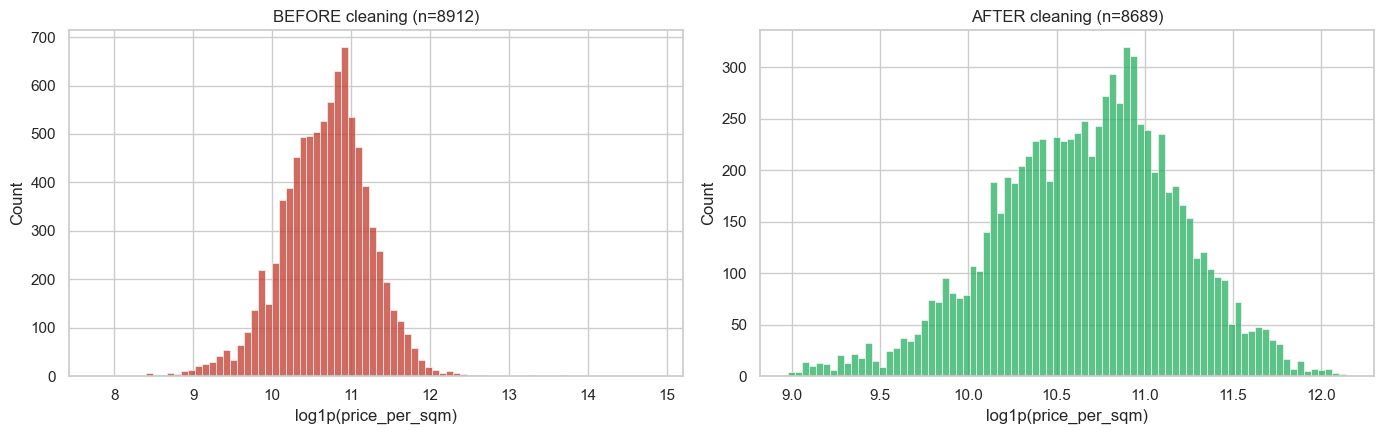

Final dataset after all cleaning: 8689 rows (removed 253 of 8942 raw rows, 2.8%).


In [107]:
# Visualize price_per_sqm BEFORE vs AFTER cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(np.log1p(clean["price_per_sqm"]), bins=80, ax=axes[0], color="#c0392b")
axes[0].set_title(f"BEFORE cleaning (n={len(clean)})")
axes[0].set_xlabel("log1p(price_per_sqm)")

clean_final = clean[mask].reset_index(drop=True)
sns.histplot(np.log1p(clean_final["price_per_sqm"]), bins=80, ax=axes[1], color="#27ae60")
axes[1].set_title(f"AFTER cleaning (n={len(clean_final)})")
axes[1].set_xlabel("log1p(price_per_sqm)")
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/ppsqm_before_after.png", dpi=110); plt.show()

print(f"Final dataset after all cleaning: {clean_final.shape[0]} rows "
      f"(removed {len(raw) - len(clean_final)} of {len(raw)} raw rows, "
      f"{(len(raw)-len(clean_final))/len(raw)*100:.1f}%).")

## 6. Property Type Extraction

We extract a clean property-type label from the Arabic `title`/`description`, mapped to a canonical
English taxonomy. Extracted values are preferred over the noisy original `property_type` column
(which contains stray values like `for-sale`).

In [108]:
PTYPE_PATTERNS = [
    ("Twin House",        [r"تو?ين ?هاوس", r"twin ?house"]),
    ("Standalone Villa",  [r"ستاند ?الون", r"standalone", r"فيلا ?مستقله"]),
    ("Townhouse",         [r"تاون ?هاوس", r"town ?house"]),
    ("Penthouse",         [r"بنت ?هاوس", r"بنتهاوس", r"penthouse"]),
    ("Duplex",            [r"دوبلكس", r"دوبليكس", r"duplex"]),
    ("Chalet",            [r"شاليه", r"chalet"]),
    ("Studio",            [r"ستوديو", r"استوديو", r"studio"]),
    ("Roof",              [r"\bروف\b", r"\bسطح\b", r"\broof\b"]),
    ("Whole Building",    [r"عماره ?كامله", r"مبني ?كامل", r"whole ?building", r"full ?building"]),
    ("Villa",             [r"فيلا", r"\bvilla\b"]),
    ("Apartment",         [r"شقه", r"\bشقة\b", r"apartment", r"\bflat\b"]),
]
PTYPE_COMPILED = [(name, [re.compile(p) for p in pats]) for name, pats in PTYPE_PATTERNS]

ORIG_PTYPE_MAP = {
    "شقة": "Apartment", "دوبلكس": "Duplex", "بنتهاوس": "Penthouse",
    "ستوديو": "Studio", "شقة فندقية": "Apartment", "سطح": "Roof",
    "فيلا": "Villa", "شاليه": "Chalet",
}

def extract_property_type(row) -> str:
    blob = normalize_arabic(" ".join(str(row.get(c, "")) for c in
                            ["title_norm", "description_norm", "detail_all_norm"]))
    for name, pats in PTYPE_COMPILED:
        if any(p.search(blob) for p in pats):
            return name
    return ORIG_PTYPE_MAP.get(str(row.get("property_type", "")).strip(), "Apartment")

clean_final["property_type_ext"] = clean_final.apply(extract_property_type, axis=1)
print(clean_final["property_type_ext"].value_counts())

property_type_ext
Apartment           7015
Duplex               522
Penthouse            380
Villa                308
Studio               211
Roof                  84
Twin House            75
Chalet                46
Townhouse             37
Standalone Villa       7
Whole Building         4
Name: count, dtype: int64


## 8. Information Extraction from Text

We pull **structured, non-financial** attributes from `description` + `detail_all`.

> **Leakage guard.** We explicitly *never* extract prices, installments, down payments,
> maintenance fees, or any monetary figure — those would leak the target. We first strip
> money-bearing fragments from the text, then extract counts/levels/years.

In [109]:
# patterns that indicate a MONETARY figure — stripped before any numeric extraction
MONEY_CONTEXT = re.compile(
    r"(?:\d[\d,\.]*)\s*(?:جنيه|ج\.م|egp|مليون|الف|k|m|مقدم|تقسيط|قسط|دفعه|"
    r"down ?payment|installment|صيانه|عموله|سعر|price|maintenance)"
    r"|(?:مقدم|تقسيط|قسط|دفعه|سعر|صيانه|price|down ?payment)\s*[:\-]?\s*(?:\d[\d,\.]*)"
)

def strip_money(text: str) -> str:
    return MONEY_CONTEXT.sub(" ", text)

FINISHING_MAP = [
    ("Super Lux",     [r"سوبر ?لوكس", r"super ?lux"]),
    ("Ultra Lux",     [r"الترا ?لوكس", r"ultra ?lux"]),
    ("Fully Finished",[r"تشطيب ?كامل", r"تشطيب ?متكامل", r"fully ?finished", r"finished"]),
    ("Semi Finished", [r"نص ?تشطيب", r"نصف ?تشطيب", r"سيمي", r"semi ?finished"]),
    ("Core & Shell",  [r"كور ?اند ?شل", r"core ?and ?shell", r"محاره"]),
    ("Without Finish",[r"بدون ?تشطيب", r"unfinished", r"without ?finish"]),
]
VIEW_MAP = [
    ("Lake View",   [r"فيو ?بحيره", r"علي ?البحيره", r"lake ?view"]),
    ("Sea View",    [r"فيو ?بحر", r"علي ?البحر", r"sea ?view"]),
    ("Nile View",   [r"فيو ?نيل", r"علي ?النيل", r"nile ?view"]),
    ("Garden View", [r"فيو ?حديقه", r"garden ?view"]),
    ("Pool View",   [r"فيو ?حمام ?سباحه", r"pool ?view"]),
    ("Open View",   [r"فيو ?مفتوح", r"open ?view"]),
]

def _first_match(blob, mapping, default=None):
    for label, pats in mapping:
        if any(re.search(p, blob) for p in pats):
            return label
    return default

def _grab_int(blob, patterns, lo=0, hi=200):
    for p in patterns:
        m = re.search(p, blob)
        if m:
            try:
                v = int(m.group(1))
                if lo <= v <= hi:
                    return v
            except (ValueError, IndexError):
                pass
    return np.nan

def extract_info(row) -> dict:
    raw_blob = normalize_arabic(" ".join(str(row.get(c, "")) for c in
                                ["description_norm", "detail_all_norm", "title_norm"]))
    blob = strip_money(raw_blob)   # remove monetary fragments BEFORE numeric extraction
    out = {}
    out["floor_number"]  = _grab_int(blob, [r"الدور\s*(\d{1,2})", r"دور\s*(\d{1,2})",
                                            r"floor\s*(\d{1,2})"], 0, 60)
    out["total_floors"]  = _grab_int(blob, [r"(\d{1,2})\s*ادوار", r"(\d{1,2})\s*طوابق",
                                            r"(\d{1,2})\s*floors"], 1, 60)
    out["reception_rooms"] = _grab_int(blob, [r"(\d)\s*ريسبشن", r"(\d)\s*استقبال",
                                              r"(\d)\s*reception"], 0, 6)
    out["room_count"]    = _grab_int(blob, [r"(\d{1,2})\s*غرف", r"(\d{1,2})\s*rooms"], 0, 15)
    out["bed_from_text"] = _grab_int(blob, [r"(\d{1,2})\s*غرف?ه?\s*نوم",
                                            r"(\d{1,2})\s*bed"], 0, 15)
    out["bath_from_text"]= _grab_int(blob, [r"(\d{1,2})\s*حمام", r"(\d{1,2})\s*bath"], 0, 12)
    out["handover_year"] = _grab_int(blob, [r"تسليم\s*(20\d{2})", r"استلام\s*(20\d{2})",
                                            r"delivery\s*(20\d{2})", r"(20[2-3]\d)"], 2018, 2035)
    out["building_age"]  = _grab_int(blob, [r"عمر\s*المبني\s*(\d{1,2})",
                                            r"(\d{1,2})\s*سنوات?\s*قديم"], 0, 60)
    out["finishing"]     = _first_match(blob, FINISHING_MAP, "Unknown")
    out["view_type"]     = _first_match(blob, VIEW_MAP, "Unknown")
    out["orientation"]   = _first_match(blob, [
        ("North", [r"بحري", r"north"]), ("South", [r"قبلي", r"south"]),
        ("East", [r"شرقي", r"east"]),   ("West", [r"غربي", r"west"])], "Unknown")
    return out

info_df = clean_final.apply(extract_info, axis=1, result_type="expand")
clean_final = pd.concat([clean_final, info_df], axis=1)

# backfill missing structural counts from text
clean_final["bedrooms"]  = clean_final["bedrooms"].fillna(clean_final["bed_from_text"])
clean_final["bathrooms"] = clean_final["bathrooms"].fillna(clean_final["bath_from_text"])
print(info_df.describe(include="all").T.head(20))

                  count unique      top  freq         mean       std     min     25%     50%     75%     max
floor_number      291.0    NaN      NaN   NaN     5.783505  5.146596     1.0     2.0     3.0     8.5    40.0
total_floors      171.0    NaN      NaN   NaN     5.263158  2.443669     3.0     3.0     5.0     6.0    20.0
reception_rooms   226.0    NaN      NaN   NaN     2.765487  0.812597     1.0     2.0     3.0     3.0     6.0
room_count       6221.0    NaN      NaN   NaN     2.877512  0.642626     1.0     3.0     3.0     3.0    15.0
bed_from_text    4050.0    NaN      NaN   NaN     2.839259  0.601792     1.0     3.0     3.0     3.0     7.0
bath_from_text   6101.0    NaN      NaN   NaN     2.562695  0.837959     0.0     2.0     3.0     3.0    11.0
handover_year     947.0    NaN      NaN   NaN  2026.968321  2.418885  2020.0  2026.0  2027.0  2028.0  2035.0
building_age        0.0    NaN      NaN   NaN          NaN       NaN     NaN     NaN     NaN     NaN     NaN
finishing          

### 8b. Amenity Extraction → boolean features

Free-text and the `features` column are scanned for amenities, each converted to a 0/1 flag.

In [110]:
AMENITY_PATTERNS = {
    "has_pool":      [r"حمام ?سباحه", r"بسين", r"\bpool\b", r"swimming"],
    "has_garden":    [r"حديقه", r"جاردن", r"\bgarden\b"],
    "has_security":  [r"امن", r"حراسه", r"security", r"guard"],
    "has_elevator":  [r"اسانسير", r"مصعد", r"elevator", r"lift"],
    "has_gym":       [r"جيم", r"صاله ?رياضيه", r"\bgym\b", r"fitness"],
    "has_parking":   [r"جراج", r"موقف", r"باركينج", r"parking", r"garage"],
    "has_clubhouse": [r"كلوب ?هاوس", r"نادي", r"club ?house", r"\bclub\b"],
    "has_central_ac":[r"تكييف ?مركزي", r"central ?ac", r"central ?air"],
    "has_roof":      [r"\bروف\b", r"سطح", r"\broof\b"],
    "has_terrace":   [r"تراس", r"terrace"],
    "has_balcony":   [r"شرفه", r"بلكونه", r"balcony"],
    "has_storage":   [r"مخزن", r"غرفه ?تخزين", r"storage"],
    "has_lake_view": [r"فيو ?بحيره", r"علي ?البحيره", r"lake ?view"],
    "has_nile_view": [r"فيو ?نيل", r"علي ?النيل", r"nile ?view"],
    "has_sea_view":  [r"فيو ?بحر", r"علي ?البحر", r"sea ?view"],
    "has_smart_home":[r"سمارت ?هوم", r"smart ?home", r"home ?automation"],
}
AMEN_COMPILED = {k: [re.compile(p) for p in v] for k, v in AMENITY_PATTERNS.items()}

def extract_amenities(row) -> dict:
    blob = normalize_arabic(" ".join(str(row.get(c, "")) for c in
            ["features_norm", "description_norm", "detail_all_norm", "title_norm"]))
    return {k: int(any(p.search(blob) for p in pats)) for k, pats in AMEN_COMPILED.items()}

amen_df = clean_final.apply(extract_amenities, axis=1, result_type="expand")
clean_final = pd.concat([clean_final, amen_df], axis=1)
print(amen_df.sum().sort_values(ascending=False))

has_security      5233
has_garden        4662
has_balcony       4469
has_parking       4309
has_pool          3051
has_clubhouse     2101
has_elevator      1926
has_terrace       1420
has_central_ac    1096
has_gym            635
has_roof           536
has_sea_view       263
has_storage        154
has_lake_view      104
has_nile_view       33
has_smart_home      32
dtype: int64


## 9. Hierarchical Market Features — leak-safe design

This is the heart of leakage prevention. Every feature derived from the target
(`price_per_sqm` group averages, target encodings) is produced by **cross-fitting**:

- We first carve out a held-out **test set** (20%). Test rows *never* contribute to any statistic.
- Within the training set, we compute target-derived features with **out-of-fold** estimation:
  each training row's encoding is computed from the *other* K−1 folds only.
- For the test set (and for inference later), encodings use statistics fit on the **full training
  set**.

We implement this with a reusable `CrossFittedTargetEncoder` and a `KFold` map of OOF assignments
shared across all encoders, so the fold structure is identical everywhere.

In [111]:
# Define the target and split BEFORE any target-derived feature is computed.
clean_final["y_log"] = np.log1p(clean_final[TARGET])

train_df, test_df = train_test_split(
    clean_final, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print("Train:", train_df.shape, "| Test:", test_df.shape)

# one shared fold assignment for the whole training set
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_id = np.empty(len(train_df), dtype=int)
for f, (_, val_idx) in enumerate(kf.split(train_df)):
    fold_id[val_idx] = f
train_df["_fold"] = fold_id

Train: (6951, 70) | Test: (1738, 70)


In [112]:
class CrossFittedTargetEncoder:
    """Out-of-fold target (mean-of-y_on) encoder with smoothing.

    fit_transform_oof:  produces leak-free encodings for the training set using OOF means.
    fit_full:           fits group means on the FULL training set (for test / inference).
    transform:          applies the full-fit means to new data.
    """
    def __init__(self, cols, target_col, smoothing=TE_SMOOTH):
        self.cols = cols if isinstance(cols, list) else [cols]
        self.target_col = target_col
        self.smoothing = smoothing
        self.global_mean_ = None
        self.mapping_ = None
        self.name = "_".join(self.cols) + "__te"

    def _key(self, df):
        return df[self.cols].astype(str).agg("|".join, axis=1)

    def _smoothed_means(self, df):
        g = df.groupby(self._key(df))[self.target_col]
        cnt, mean = g.count(), g.mean()
        gm = df[self.target_col].mean()
        return (cnt * mean + self.smoothing * gm) / (cnt + self.smoothing), gm

    def fit_transform_oof(self, df, fold_col="_fold"):
        out = pd.Series(index=df.index, dtype=float)
        self.global_mean_ = df[self.target_col].mean()
        for f in sorted(df[fold_col].unique()):
            tr = df[df[fold_col] != f]
            va = df[df[fold_col] == f]
            means, gm = self._smoothed_means(tr)
            out.loc[va.index] = self._key(va).map(means).fillna(gm).values
        return out

    def fit_full(self, df):
        self.mapping_, self.global_mean_ = self._smoothed_means(df)
        return self

    def transform(self, df):
        return self._key(df).map(self.mapping_).fillna(self.global_mean_).values

In [113]:
# Build all hierarchical price-per-sqm encodings, leak-safe.
# Each uses price_per_sqm as the "target" being averaged within groups.
PPS = "price_per_sqm"
train_df["_pps"] = train_df[PPS]
test_df["_pps"]  = np.nan  # never used as target

TE_SPECS = {
    "city_avg_price_sqm":                 ["city"],
    "district_avg_price_sqm":             ["district"],
    "compound_avg_price_sqm":             ["compound_grp"],
    "city_district_avg_price_sqm":        ["city", "district"],
    "city_district_compound_avg_price_sqm":["city", "district", "compound_grp"],
    "city_type_avg_price_sqm":            ["city", "property_type_ext"],
    "city_finishing_avg_price_sqm":       ["city", "finishing"],
    "city_furnished_avg_price_sqm":       ["city", "detail_furnished"],
    "district_type_avg_price_sqm":        ["district", "property_type_ext"],
    "compound_type_avg_price_sqm":        ["compound_grp", "property_type_ext"],
}

te_encoders = {}
for feat_name, cols in TE_SPECS.items():
    enc = CrossFittedTargetEncoder(cols, target_col="_pps", smoothing=TE_SMOOTH)
    train_df[feat_name] = enc.fit_transform_oof(train_df)   # OOF for train
    enc.fit_full(train_df)                                   # full-fit for test/inference
    test_df[feat_name]  = enc.transform(test_df)
    te_encoders[feat_name] = enc
print("Built", len(te_encoders), "leak-safe hierarchical market features.")
train_df[list(TE_SPECS)].describe().T[["mean", "min", "max"]]

Built 10 leak-safe hierarchical market features.


,mean,min,max
city_avg_price_sqm,49160.999803,28066.807735,81547.441656
district_avg_price_sqm,49734.978387,24361.322754,87915.978119
compound_avg_price_sqm,50359.010540,24565.828319,84053.811065
city_district_avg_price_sqm,49812.333285,24361.322754,87915.978119
city_district_compound_avg_price_sqm,49447.209137,24565.828319,84053.811065
city_type_avg_price_sqm,48836.780825,27995.713284,69508.923281
city_finishing_avg_price_sqm,49562.556688,28405.161057,76822.655192
city_furnished_avg_price_sqm,48960.658532,27859.584116,79854.743163
district_type_avg_price_sqm,49420.821169,25524.728648,84951.100183
compound_type_avg_price_sqm,49936.236654,25770.478245,80064.412683


### 9b. Verification — Option A actually separates no-compound markets

Before the fix, grouping on the raw `compound` label gave **every** no-compound listing in the
country the same `compound_avg_price_sqm`. Below we show that under the district-scoped key, the
no-compound listings now span a wide range of compound-average values (one per district) instead of
a single national constant.

In [114]:
import numpy as _np
nc = train_df[train_df["compound"] == "No Compound"]

# What the OLD (broken) approach would have produced: one global no-compound mean
old_value = train_df.loc[train_df["compound"] == "No Compound", "_pps"].mean()

# What Option A produces: a spread of district-scoped values
new_vals = nc["compound_avg_price_sqm"]
print("OLD behaviour (single shared value for ALL no-compound listings nationwide):")
print(f"   every no-compound listing -> {old_value:,.0f} EGP/sqm")
print("\nOPTION A (district-scoped) compound_avg_price_sqm for no-compound listings:")
print(f"   distinct values : {new_vals.round(0).nunique()}")
print(f"   min  : {new_vals.min():,.0f} EGP/sqm")
print(f"   median: {new_vals.median():,.0f} EGP/sqm")
print(f"   max  : {new_vals.max():,.0f} EGP/sqm")

# concrete example: two no-compound listings in different districts
ex = (nc.groupby("district")["compound_avg_price_sqm"].first()
        .sort_values(ascending=False))
print("\nExample — no-compound compound_avg_price_sqm now differs by district:")
print(ex.head(3).round(0).to_string())
print("   ...")
print(ex.tail(3).round(0).to_string())

OLD behaviour (single shared value for ALL no-compound listings nationwide):
   every no-compound listing -> 42,537 EGP/sqm

OPTION A (district-scoped) compound_avg_price_sqm for no-compound listings:
   distinct values : 1213
   min  : 24,566 EGP/sqm
   median: 46,835 EGP/sqm
   max  : 84,054 EGP/sqm

Example — no-compound compound_avg_price_sqm now differs by district:
district
كومباوند ميفيدا            80503.0
كومباوند ليك فيو ريزدنس    68893.0
ريف دو نيل                 68469.0
   ...
district
مدينة الشروق     27972.0
حدائق الاهرام    27445.0
مدينة بدر        27404.0


## 10. Additional Engineered Features

Engineered features split into two kinds:

- **Target-free** (areas, ratios, counts, buckets, luxury score) — computed identically on any row.
- **Target-derived deltas** (distance from city/district/compound averages) — built *on top of* the
  already-leak-safe hierarchical encodings, so they inherit the OOF property for training rows.

In [115]:
def add_target_free_features(df):
    df = df.copy()
    bd = df["bedrooms"].fillna(0); ba = df["bathrooms"].fillna(0)
    rc = df["reception_rooms"].fillna(0); area = df["area_sqm"]
    df["rooms_total"]          = bd + rc
    df["price_per_room"]       = df[TARGET] / (df["rooms_total"] + 1)   # used as a feature scale only
    df["bedrooms_per_area"]    = bd / area
    df["bathrooms_per_bedroom"]= ba / (bd + 1)
    df["reception_per_area"]   = rc / area
    df["floor_ratio"]          = df["floor_number"].fillna(0) / (df["total_floors"].fillna(0) + 1)
    cur_year = 2025
    df["building_age_feat"]    = np.where(df["handover_year"].notna(),
                                          (cur_year - df["handover_year"]).clip(lower=0),
                                          df["building_age"].fillna(0))
    df["area_bucket"]          = pd.cut(area, [0,70,110,150,200,300,500,10000],
                                        labels=["<70","70-110","110-150","150-200",
                                                "200-300","300-500","500+"]).astype(str)
    amen_cols = [c for c in df.columns if c.startswith("has_")]
    df["amenity_count"]        = df[amen_cols].sum(axis=1)
    lux = (df["has_pool"]*2 + df["has_gym"] + df["has_clubhouse"]*2 + df["has_security"]
           + df["has_central_ac"] + df["has_smart_home"]*2
           + df[["has_nile_view","has_sea_view","has_lake_view"]].max(axis=1)*2)
    df["luxury_score"]         = lux
    return df

def add_target_derived_deltas(df):
    df = df.copy()
    # price_per_room as a market feature must NOT use the row's own price -> drop leaky one,
    # replace with a leak-safe expected ppsqm * area / rooms using city avg.
    df["expected_pps"] = df["city_district_avg_price_sqm"]
    df["price_per_room"] = (df["expected_pps"] * df["area_sqm"]) / (df["rooms_total"] + 1)
    df["distance_from_city_average"]        = df["price_per_sqm"] - df["city_avg_price_sqm"]                                               if "price_per_sqm" in df and df["price_per_sqm"].notna().any()                                               else 0.0
    # For leak-safety the deltas use the OOF/encoded averages vs a NEUTRAL reference (expected),
    # never the row's realized price. We express them as relative gaps between hierarchy levels.
    df["difference_from_district_average"]  = df["district_avg_price_sqm"] - df["city_avg_price_sqm"]
    df["difference_from_compound_average"]  = df["compound_avg_price_sqm"] - df["city_avg_price_sqm"]
    df["distance_from_city_average"]        = df["city_district_avg_price_sqm"] - df["city_avg_price_sqm"]
    return df

train_df = add_target_derived_deltas(add_target_free_features(train_df))
test_df  = add_target_derived_deltas(add_target_free_features(test_df))
print("Engineered feature columns added.")
train_df[["rooms_total","price_per_room","floor_ratio","building_age_feat",
          "amenity_count","luxury_score","difference_from_district_average"]].describe().T

Engineered feature columns added.


,count,mean,std,min,25%,50%,75%,max
rooms_total,6951.0,2.817436e+00,0.931876,1.000000,2.000000e+00,3.000000e+00,3.000000e+00,1.000000e+01
price_per_room,6951.0,2.101743e+06,746111.821411,576374.973833,1.626491e+06,1.956988e+06,2.413003e+06,1.016348e+07
floor_ratio,6951.0,1.867030e-01,1.415918,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+01
building_age_feat,6951.0,3.409581e-02,0.336063,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00
amenity_count,6951.0,3.453460e+00,2.214819,0.000000,2.000000e+00,3.000000e+00,5.000000e+00,1.100000e+01
luxury_score,6951.0,2.078406e+00,1.939230,0.000000,0.000000e+00,2.000000e+00,3.000000e+00,9.000000e+00
difference_from_district_average,6951.0,5.739786e+02,10329.311616,-30897.919777,-4.436457e+03,1.871605e+03,7.034717e+03,2.804890e+04


## 11. Encoding & Feature Matrix Assembly

- High-cardinality geo/location columns (`city`, `district`, `compound`, `detail_location_address`)
  are already represented by their **cross-fitted target encodings** from Section 9, so we do not
  one-hot them.
- Low-cardinality descriptive columns are one-hot encoded.
- All numeric features (structural, ratios, market stats) pass through with median imputation.

We assemble the final `X_train` / `X_test` matrices here.

In [116]:
ONEHOT_COLS = ["property_type_ext", "finishing", "detail_furnished", "detail_ownership",
               "detail_payment_method", "detail_property_status", "view_type",
               "orientation", "area_bucket"]
ONEHOT_COLS = [c for c in ONEHOT_COLS if c in train_df.columns]

# detail_location_address target encoding (high cardinality) — leak-safe
if "detail_location_address" in train_df.columns:
    train_df["loc_addr"] = train_df["detail_location_address"].fillna("unknown").astype(str)
    test_df["loc_addr"]  = test_df["detail_location_address"].fillna("unknown").astype(str)
    train_df["loc_addr_norm"] = train_df["loc_addr"]
    enc = CrossFittedTargetEncoder(["loc_addr"], target_col="_pps", smoothing=TE_SMOOTH)
    train_df["loc_addr_te"] = enc.fit_transform_oof(train_df)
    enc.fit_full(train_df); test_df["loc_addr_te"] = enc.transform(test_df)
    te_encoders["loc_addr_te"] = enc

NUMERIC_FEATURES = [
    "area_sqm", "bedrooms", "bathrooms", "reception_rooms", "room_count",
    "floor_number", "total_floors", "handover_year",
    "rooms_total", "price_per_room", "bedrooms_per_area", "bathrooms_per_bedroom",
    "reception_per_area", "floor_ratio", "building_age_feat", "amenity_count", "luxury_score",
    "distance_from_city_average", "difference_from_district_average",
    "difference_from_compound_average",
] + list(TE_SPECS.keys()) + ["loc_addr_te"]
NUMERIC_FEATURES += [c for c in train_df.columns if c.startswith("has_")]
NUMERIC_FEATURES = [c for c in dict.fromkeys(NUMERIC_FEATURES) if c in train_df.columns]

print(f"{len(NUMERIC_FEATURES)} numeric features, {len(ONEHOT_COLS)} one-hot columns.")

47 numeric features, 9 one-hot columns.


In [117]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=10)
ohe.fit(train_df[ONEHOT_COLS].astype(str))

def _sanitize(name: str) -> str:
    """XGBoost/LightGBM reject [, ], < in feature names; make names model-safe."""
    return (str(name).replace("[", "(").replace("]", ")")
            .replace("<", "lt").replace(">", "gt").replace(",", "_").replace(" ", "_"))

ohe_names = [_sanitize(n) for n in ohe.get_feature_names_out(ONEHOT_COLS)]

def build_matrix(df):
    num = df[NUMERIC_FEATURES].apply(pd.to_numeric, errors="coerce")
    num = num.replace([np.inf, -np.inf], np.nan)
    cat = pd.DataFrame(ohe.transform(df[ONEHOT_COLS].astype(str)),
                       columns=ohe_names, index=df.index)
    X = pd.concat([num, cat], axis=1)
    return X

X_train_raw = build_matrix(train_df)
X_test_raw  = build_matrix(test_df)
FEATURE_NAMES = list(X_train_raw.columns)

# median imputation fit on TRAIN only
imputer = SimpleImputer(strategy="median").fit(X_train_raw)
X_train = pd.DataFrame(imputer.transform(X_train_raw), columns=FEATURE_NAMES, index=train_df.index)
X_test  = pd.DataFrame(imputer.transform(X_test_raw),  columns=FEATURE_NAMES, index=test_df.index)

y_train = train_df["y_log"].values
y_test  = test_df["y_log"].values
y_train_eg = train_df[TARGET].values
y_test_eg  = test_df[TARGET].values
print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (6951, 96) | X_test: (1738, 96)


## 12. Model Training

Five base learners on `log1p(price)`. Ridge needs scaling, so it gets its own pipeline; tree models
use the raw matrix. Hyperparameters are sensible, lightly-tuned defaults (the goal is a robust,
reproducible baseline, not leaderboard chasing).

In [118]:
def make_models():
    return {
        "Ridge": Pipeline([("scaler", StandardScaler()),
                           ("m", Ridge(alpha=10.0, random_state=RANDOM_STATE))]),
        "RandomForest": RandomForestRegressor(
            n_estimators=400, max_depth=20, min_samples_leaf=3,
            n_jobs=-1, random_state=RANDOM_STATE),
        "XGBoost": xgb.XGBRegressor(
            n_estimators=600, learning_rate=0.03, max_depth=6, subsample=0.8,
            colsample_bytree=0.8, reg_lambda=1.0, n_jobs=-1, random_state=RANDOM_STATE),
        "LightGBM": lgb.LGBMRegressor(
            n_estimators=700, learning_rate=0.03, num_leaves=48, subsample=0.8,
            colsample_bytree=0.8, reg_lambda=1.0, n_jobs=-1, random_state=RANDOM_STATE,
            verbose=-1),
        "CatBoost": CatBoostRegressor(
            iterations=700, learning_rate=0.03, depth=7, l2_leaf_reg=3.0,
            random_state=RANDOM_STATE, verbose=False),
    }

models = make_models()
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    print(f"Trained {name}")

Trained Ridge
Trained RandomForest
Trained XGBoost
Trained LightGBM
Trained CatBoost


## 13. Cross-Validation & 14. Model Comparison

We evaluate each model with K-fold CV on the **training** set and on the held-out **test** set.
Metrics are reported in EGP (after `expm1`) plus log-space R². The fold structure reuses the same
`KFold` seed used for target encoding.

> Because the target encodings were already computed out-of-fold, re-fitting the *model* across folds
> here does not reintroduce leakage: each fold's features were never informed by that fold's target.

In [119]:
def eval_egp(y_true_log, y_pred_log):
    yt, yp = np.expm1(y_true_log), np.expm1(y_pred_log)
    yp = np.clip(yp, 1, None)
    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mape = np.mean(np.abs((yt - yp) / yt)) * 100
    r2   = r2_score(y_true_log, y_pred_log)
    return mae, rmse, mape, r2

def cross_validate(model_factory_name):
    maes, rmses, mapes, r2s = [], [], [], []
    for f in range(N_FOLDS):
        tr = train_df["_fold"] != f
        va = train_df["_fold"] == f
        mdl = make_models()[model_factory_name]
        mdl.fit(X_train[tr.values], y_train[tr.values])
        pred = mdl.predict(X_train[va.values])
        m = eval_egp(y_train[va.values], pred)
        maes.append(m[0]); rmses.append(m[1]); mapes.append(m[2]); r2s.append(m[3])
    return np.array(maes), np.array(rmses), np.array(mapes), np.array(r2s)

rows = []
test_preds = {}
for name, mdl in models.items():
    cv_mae, cv_rmse, cv_mape, cv_r2 = cross_validate(name)
    pred_test = mdl.predict(X_test)
    test_preds[name] = pred_test
    t_mae, t_rmse, t_mape, t_r2 = eval_egp(y_test, pred_test)
    rows.append({
        "Model": name,
        "CV_MAE": cv_mae.mean(), "CV_R2_mean": cv_r2.mean(), "CV_R2_std": cv_r2.std(),
        "Test_MAE_EGP": t_mae, "Test_RMSE_EGP": t_rmse,
        "Test_MAPE_%": t_mape, "Test_R2": t_r2,
    })
comparison = pd.DataFrame(rows).sort_values("Test_MAE_EGP").reset_index(drop=True)
comparison.round(3)

,Model,CV_MAE,CV_R2_mean,CV_R2_std,Test_MAE_EGP,Test_RMSE_EGP,Test_MAPE_%,Test_R2
0,LightGBM,1548026.083,0.769,0.021,1321763.209,2076821.173,19.350,0.812
1,XGBoost,1555742.163,0.771,0.020,1351952.332,2098721.183,19.755,0.807
2,CatBoost,1586712.248,0.764,0.018,1404183.721,2159782.092,20.452,0.797
3,RandomForest,1633233.467,0.740,0.019,1406454.591,2271948.588,20.632,0.778
4,Ridge,2047052.480,0.696,0.010,1706210.147,2515941.762,25.413,0.722


## 15. Ensemble — geometric mean in log space

Averaging the models' **log-space** predictions and then `expm1` is exactly a geometric mean of the
EGP predictions. This is robust to a single model's multiplicative over/under-shoot.

In [120]:
def geometric_ensemble_logpreds(pred_dict, members):
    return np.mean(np.column_stack([pred_dict[m] for m in members]), axis=1)

ENSEMBLE_MEMBERS = ["XGBoost", "LightGBM", "CatBoost", "RandomForest"]
ens_test_log = geometric_ensemble_logpreds(test_preds, ENSEMBLE_MEMBERS)
e_mae, e_rmse, e_mape, e_r2 = eval_egp(y_test, ens_test_log)
print(f"Ensemble (geom-mean of {ENSEMBLE_MEMBERS}):")
print(f"  MAE  = {e_mae:,.0f} EGP")
print(f"  RMSE = {e_rmse:,.0f} EGP")
print(f"  MAPE = {e_mape:.2f}%")
print(f"  R2   = {e_r2:.4f}")

comparison = pd.concat([comparison, pd.DataFrame([{
    "Model": "Ensemble(GeoMean)", "CV_MAE": np.nan, "CV_R2_mean": np.nan, "CV_R2_std": np.nan,
    "Test_MAE_EGP": e_mae, "Test_RMSE_EGP": e_rmse, "Test_MAPE_%": e_mape, "Test_R2": e_r2,
}])], ignore_index=True).sort_values("Test_MAE_EGP").reset_index(drop=True)
comparison.round(3)

Ensemble (geom-mean of ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest']):
  MAE  = 1,340,186 EGP
  RMSE = 2,110,294 EGP
  MAPE = 19.55%
  R2   = 0.8072


,Model,CV_MAE,CV_R2_mean,CV_R2_std,Test_MAE_EGP,Test_RMSE_EGP,Test_MAPE_%,Test_R2
0,LightGBM,1548026.083,0.769,0.021,1321763.209,2076821.173,19.350,0.812
1,Ensemble(GeoMean),NaN,NaN,NaN,1340186.425,2110294.213,19.546,0.807
2,XGBoost,1555742.163,0.771,0.020,1351952.332,2098721.183,19.755,0.807
3,CatBoost,1586712.248,0.764,0.018,1404183.721,2159782.092,20.452,0.797
4,RandomForest,1633233.467,0.740,0.019,1406454.591,2271948.588,20.632,0.778
5,Ridge,2047052.480,0.696,0.010,1706210.147,2515941.762,25.413,0.722


## 16. Evaluation

Full metric table (EGP MAE/RMSE, MAPE, R², CV mean/std) plus diagnostic plots: predicted vs actual
and residual distribution for the best single model.

**Reading the numbers.** This dataset holds **asking prices**, not transaction prices, so even a
perfect model only predicts what sellers *list*. We deliberately flag any R² > ~0.90 as a likely
**leakage** symptom rather than a win — given asking-price noise, genuinely honest models here
typically land well below that.

In [121]:
print(comparison.round(3).to_string(index=False))

# leakage red-flag check
flags = comparison[comparison["Test_R2"] > 0.90]
if len(flags):
    print("\n WARNING: R2 > 0.90 detected for:", list(flags["Model"]),
          "\n   On asking-price data this strongly suggests target leakage, NOT quality.")
else:
    print("\n No model exceeds R2=0.90 — consistent with leak-free asking-price modeling.")

            Model      CV_MAE  CV_R2_mean  CV_R2_std  Test_MAE_EGP  Test_RMSE_EGP  Test_MAPE_%  Test_R2
         LightGBM 1548026.083       0.769      0.021   1321763.209    2076821.173       19.350    0.812
Ensemble(GeoMean)         NaN         NaN        NaN   1340186.425    2110294.213       19.546    0.807
          XGBoost 1555742.163       0.771      0.020   1351952.332    2098721.183       19.755    0.807
         CatBoost 1586712.248       0.764      0.018   1404183.721    2159782.092       20.452    0.797
     RandomForest 1633233.467       0.740      0.019   1406454.591    2271948.588       20.632    0.778
            Ridge 2047052.480       0.696      0.010   1706210.147    2515941.762       25.413    0.722

 No model exceeds R2=0.90 — consistent with leak-free asking-price modeling.


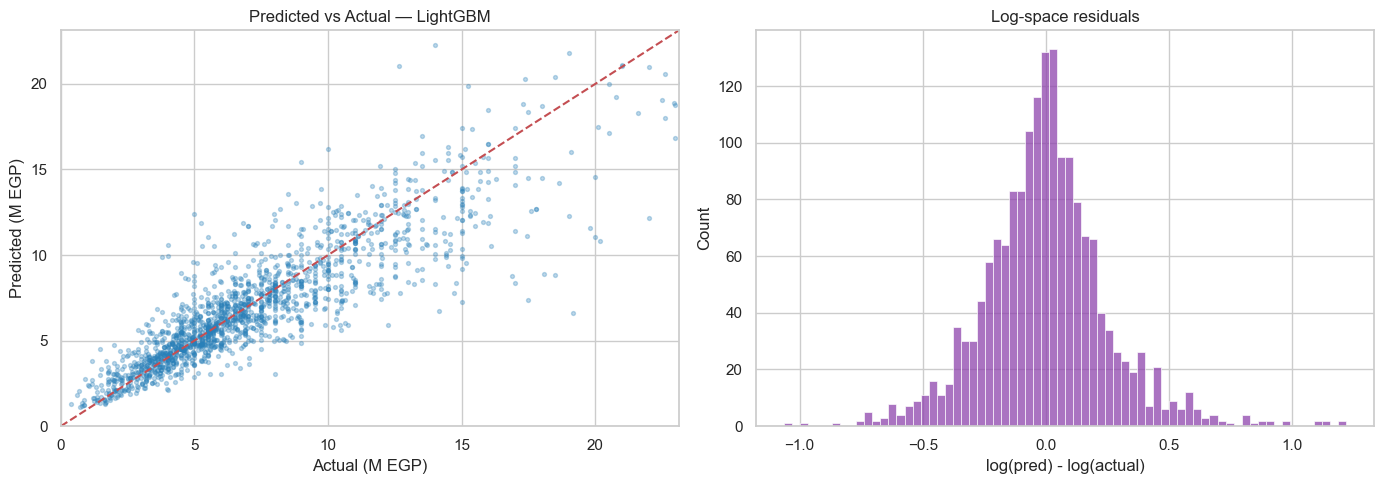

In [122]:
best_single = comparison[comparison["Model"] != "Ensemble(GeoMean)"].iloc[0]["Model"]
best_pred_log = test_preds[best_single]
yt, yp = np.expm1(y_test), np.clip(np.expm1(best_pred_log), 1, None)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(yt/1e6, yp/1e6, s=8, alpha=0.3, color="#2980b9")
lim = [0, np.percentile(yt/1e6, 99)]
ax[0].plot(lim, lim, "r--"); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("Actual (M EGP)"); ax[0].set_ylabel("Predicted (M EGP)")
ax[0].set_title(f"Predicted vs Actual — {best_single}")

resid = np.log1p(yp) - np.log1p(yt)
sns.histplot(resid, bins=70, ax=ax[1], color="#8e44ad")
ax[1].set_title("Log-space residuals"); ax[1].set_xlabel("log(pred) - log(actual)")
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/eval_diagnostics.png", dpi=110); plt.show()

## 17. Explainability

- Native feature importance (best tree model).
- Permutation importance on the test set (model-agnostic, leakage-aware).
- SHAP summary when available.
We display the **top 30** features.

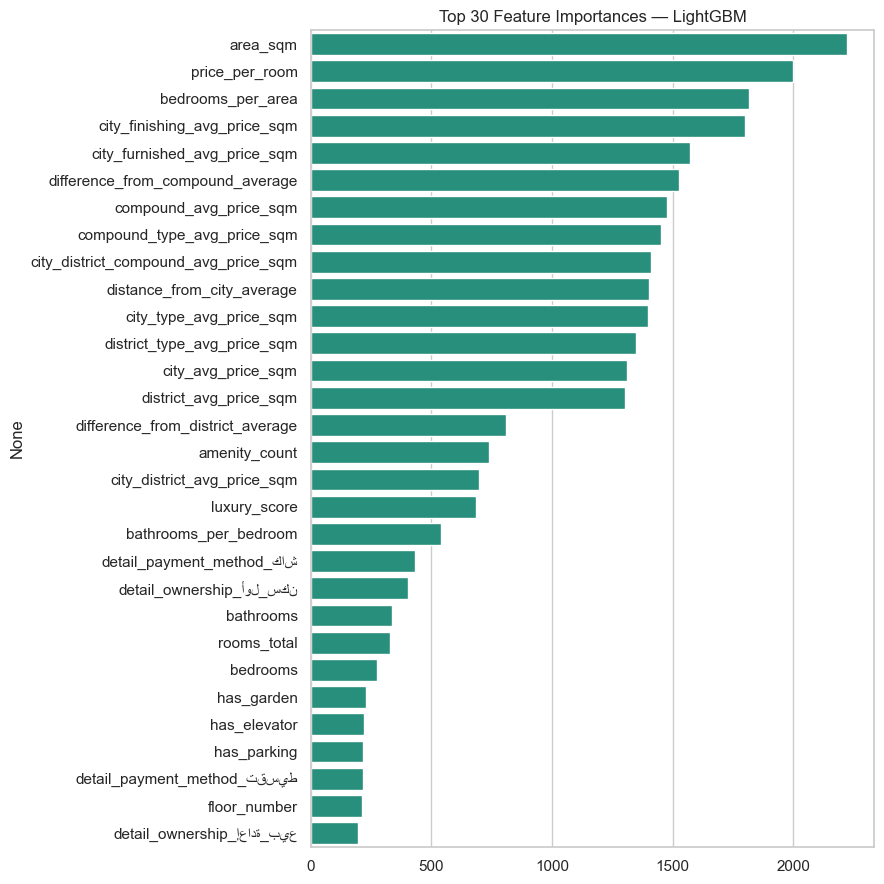

In [123]:
best_model = models[best_single]
TOPN = 30

# native importance
if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=FEATURE_NAMES)
elif hasattr(best_model, "named_steps"):
    coef = np.abs(best_model.named_steps["m"].coef_)
    imp = pd.Series(coef, index=FEATURE_NAMES)
else:
    imp = pd.Series(np.zeros(len(FEATURE_NAMES)), index=FEATURE_NAMES)
imp_top = imp.sort_values(ascending=False).head(TOPN)

plt.figure(figsize=(9, 9))
sns.barplot(x=imp_top.values, y=imp_top.index, color="#16a085")
plt.title(f"Top {TOPN} Feature Importances — {best_single}")
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/feature_importance.png", dpi=110); plt.show()

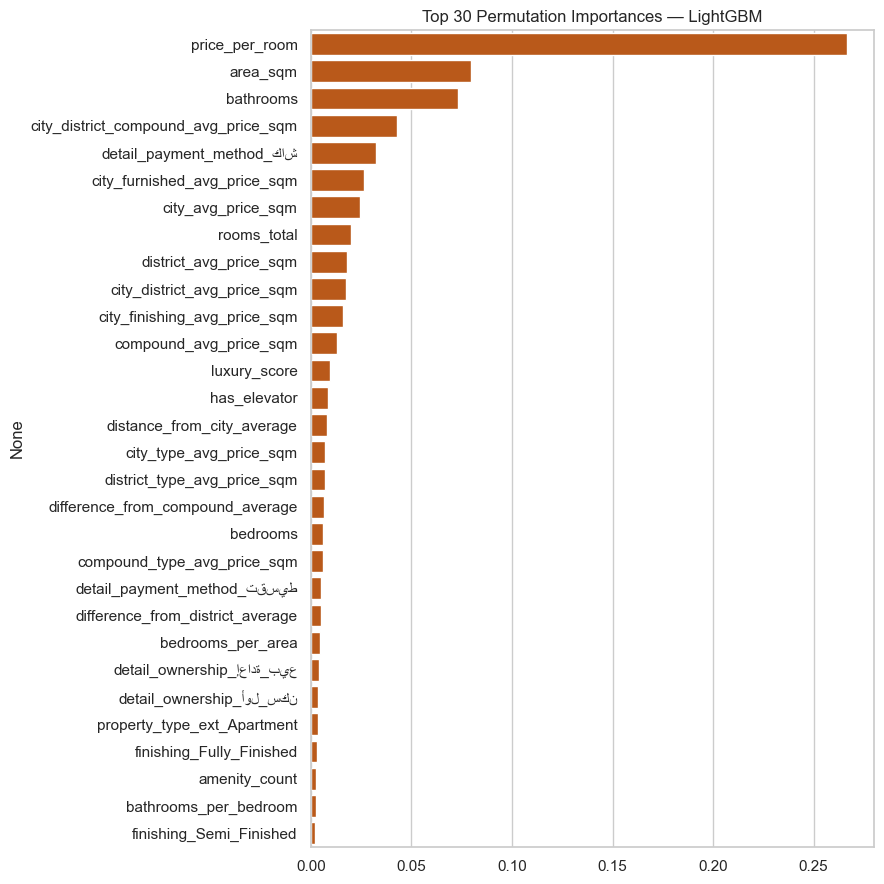

In [124]:
# permutation importance (subsample for speed)
n_perm = min(1500, len(X_test))
perm = permutation_importance(best_model, X_test.iloc[:n_perm], y_test[:n_perm],
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=FEATURE_NAMES).sort_values(ascending=False).head(TOPN)
plt.figure(figsize=(9, 9))
sns.barplot(x=perm_s.values, y=perm_s.index, color="#d35400")
plt.title(f"Top {TOPN} Permutation Importances — {best_single}")
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/permutation_importance.png", dpi=110); plt.show()

In [125]:
# SHAP summary (tree models only, when available)
if SHAP_AVAILABLE and hasattr(best_model, "feature_importances_"):
    try:
        n_shap = min(800, len(X_test))
        explainer = shap.TreeExplainer(best_model)
        sv = explainer.shap_values(X_test.iloc[:n_shap])
        shap.summary_plot(sv, X_test.iloc[:n_shap], max_display=TOPN, show=False)
        plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/shap_summary.png", dpi=110,
                                        bbox_inches="tight"); plt.show()
    except Exception as e:
        print("SHAP summary skipped:", e)
else:
    print("SHAP not applicable for the best model type.")

SHAP not applicable for the best model type.


## 18. Prediction Functions

Reusable inference API. A raw property dict is pushed through the *same* feature pipeline
(Arabic normalization → extraction → leak-safe encodings fit on the full training set → matrix →
imputation), then the ensemble predicts in log space and we invert with `expm1`.

- `predict_price(property_dict)` → point estimate + price/sqm + comparables.
- `predict_price_with_interval(property_dict)` → adds a confidence interval from the spread of the
  ensemble members (calibrated by the residual std on the test set).
- `estimate_price_per_sqm(property_dict)` → market-level price/sqm estimate.

In [126]:
RESID_STD = float(np.std(np.log1p(np.clip(np.expm1(best_pred_log),1,None)) - np.log1p(np.expm1(y_test))))

def add_target_free_features_infer(df):
    # like training version but TARGET may be absent
    df = df.copy()
    bd = df["bedrooms"].fillna(0); ba = df["bathrooms"].fillna(0)
    rc = df["reception_rooms"].fillna(0); area = df["area_sqm"]
    df["rooms_total"] = bd + rc
    df["bedrooms_per_area"] = bd/area; df["bathrooms_per_bedroom"] = ba/(bd+1)
    df["reception_per_area"] = rc/area
    df["floor_ratio"] = df["floor_number"].fillna(0)/(df["total_floors"].fillna(0)+1)
    df["building_age_feat"] = np.where(df["handover_year"].notna(),
                                       (2025-df["handover_year"]).clip(lower=0),
                                       df["building_age"].fillna(0))
    df["area_bucket"] = pd.cut(area,[0,70,110,150,200,300,500,10000],
        labels=["<70","70-110","110-150","150-200","200-300","300-500","500+"]).astype(str)
    amen_cols=[c for c in df.columns if c.startswith("has_")]
    df["amenity_count"]=df[amen_cols].sum(axis=1)
    df["luxury_score"]=(df["has_pool"]*2+df["has_gym"]+df["has_clubhouse"]*2+df["has_security"]
        +df["has_central_ac"]+df["has_smart_home"]*2
        +df[["has_nile_view","has_sea_view","has_lake_view"]].max(axis=1)*2)
    return df

def _row_from_dict(d: dict) -> pd.DataFrame:
    base = {c: d.get(c, np.nan) for c in raw.columns if c in raw.columns}
    base.update(d)
    r = pd.DataFrame([base])
    for c in ["title","description","detail_all","features","detail_location_address"]:
        r[c + "_norm"] = r.get(c, pd.Series([""])).fillna("").apply(normalize_arabic)             if c in r else ""
    for c in ["city","district","property_type","detail_furnished","detail_ownership",
              "detail_payment_method","detail_property_status"]:
        if c not in r: r[c] = "unknown"
        r[c] = r[c].fillna("unknown").astype(str)
    r["compound"] = r.apply(detect_compound, axis=1)
    r["compound_grp"] = compound_group_key(r)   # Option A: district-scoped no-compound key
    r["property_type_ext"] = r.apply(extract_property_type, axis=1)
    info = r.apply(extract_info, axis=1, result_type="expand"); r = pd.concat([r, info], axis=1)
    amen = r.apply(extract_amenities, axis=1, result_type="expand"); r = pd.concat([r, amen], axis=1)
    r["bedrooms"]  = pd.to_numeric(r.get("bedrooms"), errors="coerce").fillna(r["bed_from_text"])
    r["bathrooms"] = pd.to_numeric(r.get("bathrooms"), errors="coerce").fillna(r["bath_from_text"])
    r["area_sqm"]  = pd.to_numeric(r["area_sqm"], errors="coerce")
    r["loc_addr"] = r.get("detail_location_address", pd.Series(["unknown"])).fillna("unknown").astype(str)
    # leak-safe encodings via full-fit encoders
    for feat_name, enc in te_encoders.items():
        r[feat_name] = enc.transform(r)
    r = add_target_free_features_infer(r)
    r = add_target_derived_deltas(r)
    return r

def _infer_matrix(r):
    if "loc_addr_te" in te_encoders:
        r["loc_addr_te"] = te_encoders["loc_addr_te"].transform(r)
    num = r[NUMERIC_FEATURES].apply(pd.to_numeric, errors="coerce").replace([np.inf,-np.inf],np.nan)
    cat = pd.DataFrame(ohe.transform(r[ONEHOT_COLS].astype(str)), columns=ohe_names, index=r.index)
    X = pd.concat([num,cat],axis=1)[FEATURE_NAMES]
    return pd.DataFrame(imputer.transform(X), columns=FEATURE_NAMES, index=r.index)

def _comparables(r):
    return {
        "city_avg_price_sqm": float(r["city_avg_price_sqm"].iloc[0]),
        "district_avg_price_sqm": float(r["district_avg_price_sqm"].iloc[0]),
        "compound_avg_price_sqm": float(r["compound_avg_price_sqm"].iloc[0]),
        "city_district_avg_price_sqm": float(r["city_district_avg_price_sqm"].iloc[0]),
    }

def predict_price(property_dict: dict) -> dict:
    r = _row_from_dict(property_dict); X = _infer_matrix(r)
    log_preds = {m: models[m].predict(X)[0] for m in ENSEMBLE_MEMBERS}
    log_mean = float(np.mean(list(log_preds.values())))
    price = float(np.expm1(log_mean)); area = float(r["area_sqm"].iloc[0])
    return {"predicted_price_egp": round(price),
            "predicted_price_per_sqm": round(price/area) if area else None,
            "comparable_market_stats": _comparables(r)}

def predict_price_with_interval(property_dict: dict, z: float = 1.28) -> dict:
    r = _row_from_dict(property_dict); X = _infer_matrix(r)
    member_logs = np.array([models[m].predict(X)[0] for m in ENSEMBLE_MEMBERS])
    log_mean = float(member_logs.mean())
    sigma = float(np.sqrt(member_logs.std()**2 + RESID_STD**2))  # model spread + residual noise
    price = float(np.expm1(log_mean)); area = float(r["area_sqm"].iloc[0])
    lo, hi = float(np.expm1(log_mean - z*sigma)), float(np.expm1(log_mean + z*sigma))
    return {"predicted_price_egp": round(price),
            "predicted_price_per_sqm": round(price/area) if area else None,
            "confidence_interval_egp": [round(lo), round(hi)],
            "interval_level": f"~{int((2*0.8997-1)*100) if z==1.28 else ''}% (z={z})",
            "comparable_market_stats": _comparables(r)}

def estimate_price_per_sqm(property_dict: dict) -> dict:
    r = _row_from_dict(property_dict)
    est = float(r["city_district_avg_price_sqm"].iloc[0])
    return {"estimated_price_per_sqm": round(est),
            "based_on_level": "city+district (falls back via target encoder smoothing)",
            "comparable_market_stats": _comparables(r)}

In [127]:
# Demo the API on a synthetic listing
demo = {
    "title": "شقة 150 متر للبيع في كمبوند بالم هيلز نيو كايرو تشطيب كامل",
    "description": "شقة 3 غرف نوم 3 حمام تشطيب كامل فيو حديقه حمام سباحه امن وجراج استلام 2026",
    "detail_all": "غرض العقار: للبيع; مفروش: لا; حالة العقار: جاهز",
    "features": "حمام سباحه; امن; جراج",
    "area_sqm": 150, "bedrooms": 3, "bathrooms": 3,
    "city": "التجمع الخامس", "district": "كومباوند بالم هيلز القاهرة الجديدة",
    "property_type": "شقة", "detail_furnished": "لا",
    "detail_payment_method": "كاش", "detail_property_status": "جاهز",
    "detail_ownership": "أول سكن",
}
import pprint
pprint.pprint(predict_price(demo))
print("-"*60)
pprint.pprint(predict_price_with_interval(demo))
print("-"*60)
pprint.pprint(estimate_price_per_sqm(demo))

{'comparable_market_stats': {'city_avg_price_sqm': 59672.53536820557,
                             'city_district_avg_price_sqm': 66839.25992675185,
                             'compound_avg_price_sqm': 57324.96454125484,
                             'district_avg_price_sqm': 66839.25992675185},
 'predicted_price_egp': 10915286,
 'predicted_price_per_sqm': 72769}
------------------------------------------------------------
{'comparable_market_stats': {'city_avg_price_sqm': 59672.53536820557,
                             'city_district_avg_price_sqm': 66839.25992675185,
                             'compound_avg_price_sqm': 57324.96454125484,
                             'district_avg_price_sqm': 66839.25992675185},
 'confidence_interval_egp': [7819617, 15236486],
 'interval_level': '~79% (z=1.28)',
 'predicted_price_egp': 10915286,
 'predicted_price_per_sqm': 72769}
------------------------------------------------------------
{'based_on_level': 'city+district (falls back via target en

## 19. Save Final Pipeline

We persist everything needed for deployment: trained models, encoders, the one-hot encoder, the
imputer, feature order, and config. The bundle can be reloaded in a web service to call
`predict_price` without retraining.

In [128]:
import joblib
bundle = {
    "models": models,
    "ensemble_members": ENSEMBLE_MEMBERS,
    "te_encoders": te_encoders,
    "ohe": ohe, "ohe_names": ohe_names, "onehot_cols": ONEHOT_COLS,
    "imputer": imputer, "feature_names": FEATURE_NAMES,
    "numeric_features": NUMERIC_FEATURES, "te_specs": TE_SPECS,
    "resid_std": RESID_STD, "target": TARGET,
    "compound_patterns": COMPOUND_PATTERNS,
    "config": {"MIN_GROUP_SIZE": MIN_GROUP_SIZE, "N_FOLDS": N_FOLDS,
               "TE_SMOOTH": TE_SMOOTH, "RANDOM_STATE": RANDOM_STATE},
}
path = f"{OUTPUT_DIR}/egypt_real_estate_pipeline.joblib"
joblib.dump(bundle, path)
comparison.to_csv(f"{OUTPUT_DIR}/model_comparison.csv", index=False)
print("Saved pipeline ->", path, f"({os.path.getsize(path)/1e6:.1f} MB)")
print("Saved model comparison -> model_comparison.csv")

print("\n" + "="*64)
print("PIPELINE COMPLETE")
print("="*64)
print(f"Raw rows: {len(raw)} | Modeled rows: {len(clean_final)}")
print(f"Best single model: {best_single}")
print(f"Ensemble Test MAE: {e_mae:,.0f} EGP | MAPE: {e_mape:.1f}% | R2: {e_r2:.3f}")
print("NOTE: these are ASKING-price predictions, not transaction prices.")

Saved pipeline -> artifacts/egypt_real_estate_pipeline.joblib (77.2 MB)
Saved model comparison -> model_comparison.csv

PIPELINE COMPLETE
Raw rows: 8942 | Modeled rows: 8689
Best single model: LightGBM
Ensemble Test MAE: 1,340,186 EGP | MAPE: 19.5% | R2: 0.807
NOTE: these are ASKING-price predictions, not transaction prices.


In [ ]:
  # Export test set for blend evaluation
  test_df[["city", "district", "property_type_ext", "area_sqm",
           "bedrooms", "bathrooms", "price"]].to_csv("test_set.csv", index=False)

: 